In [1]:
from qiskit import __version__

print(__version__)

2.4.2


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## Task 1: Implement quantum circuit description of the teleportation protocol.

___
**Step 1: Set up quantum circuit**

In [7]:
qubit = QuantumRegister(1, "Q")

ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

**S2: Prepare ebit used for teleportation**

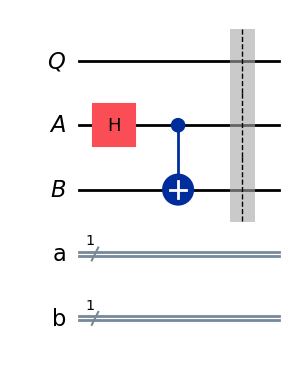

In [8]:
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)

protocol.barrier()

protocol.draw(output="mpl")

**Step 3: Alice's Operations**

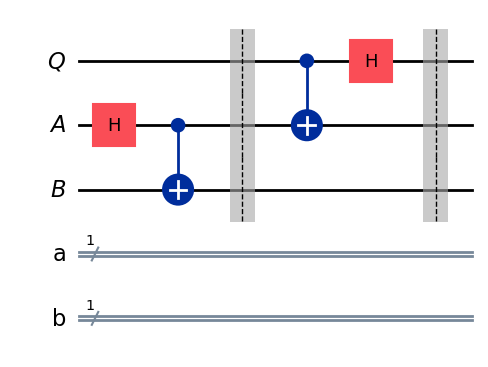

In [9]:
protocol.cx(qubit, ebit0)
protocol.h(qubit)

protocol.barrier()
protocol.draw(output="mpl")

**S4: Alice measures and sends classical bits to Bob**

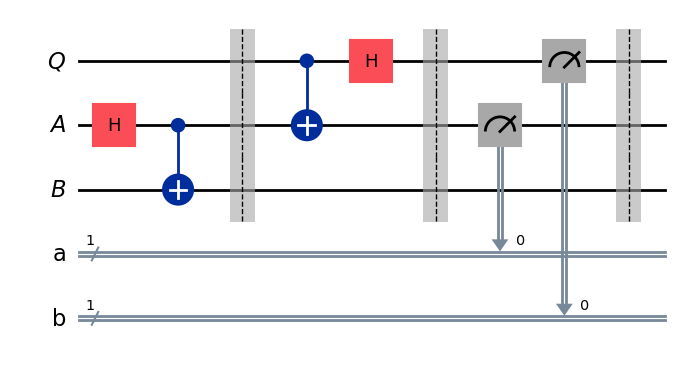

In [10]:
protocol.measure(ebit0, a)
protocol.measure(qubit, b)

protocol.barrier()
protocol.draw(output="mpl")

**S5: Bob uses the classical bits to conditionally apply gates**

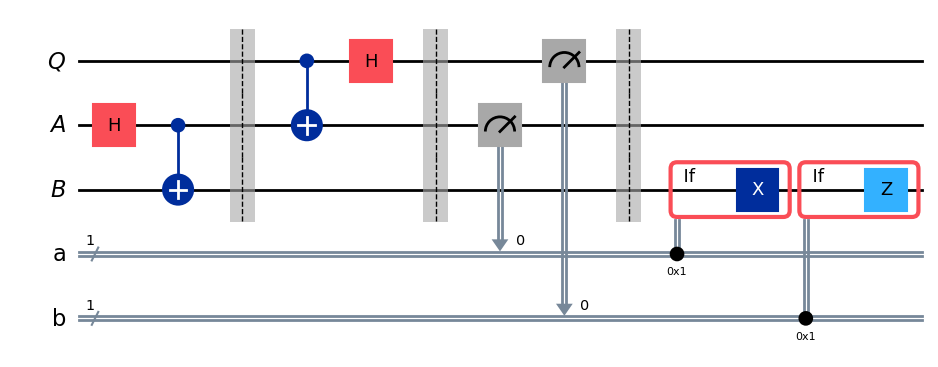

In [11]:
with protocol.if_test((a, 1)):
    protocol.x(ebit1)

with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))

___
The circuit makes use of a few features of Qiskit that we've not yet seen in previous lessons, including the barrier and if_test functions. 

The __barrier__ function creates a visual separation making the circuit diagram more readable, and it also prevents Qiskit from performing various simplifications and optimizations across the barrier during compilation when circuits are run on real hardware. 

The __if_test__ function applies an operation conditionally depending on a classical bit or register.

## Task 2: Verify that the protocol works with 

## UU-dagger = I condition

___
The circuit first initializes **(A,B)** to be in a **∣ϕ+⟩** state 
(which is not part of the protocol itself), 
followed by Alice's operations, 
then her measurements, 
and finally Bob's operations. 

To test that the protocol works correctly, we'll apply a randomly generated single-qubit gate to the initialized **∣0⟩** state of **Q** to obtain a random quantum state vector to be teleported. 

By applying the inverse (as in, the conjugate transpose) of that gate to **B** after the protocol is run, we can verify that the state was teleported by measuring to see that it has returned to the **∣0⟩** state.

___
**Step 1: First we'll randomly choose a unitary qubit gate.**

____
**For a general U gate, the matrix is:**

$U(θ,ϕ,λ)=[cos(θ/2) eiϕsin(θ/2) ​− eiλsin(θ/2) ei(ϕ+λ)cos(θ/2)​]$

*The 2nd terms in each term is actually the 2nd row lol*

In [13]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

**S2: Create a new testing circuit**

___
Now we'll create a new testing circuit that first applies our random gate to Q, 
then runs the teleportation circuit, 
and finally applies the inverse of our random gate to the qubit B and measures. 

The outcome should be 0 with certainty.

In [14]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

**S3: Start with the randomly selected gate on Q**

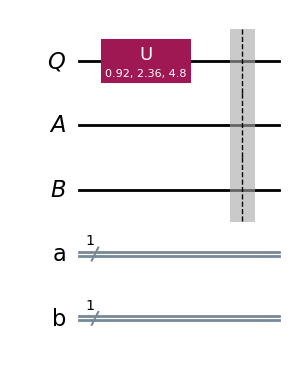

In [15]:
test.append(random_gate, qubit)
test.barrier()

test.draw(output="mpl")

**S4: Append the entire teleportation protocol from above.**

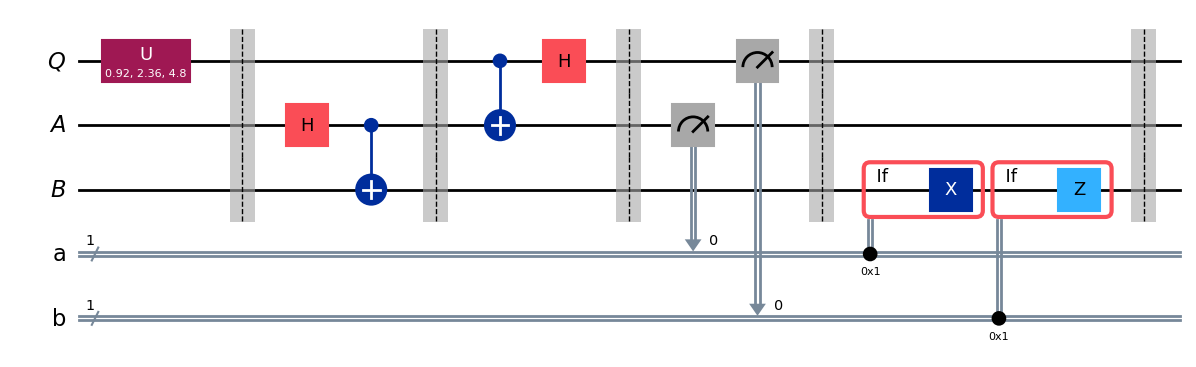

In [16]:
test = test.compose(protocol)
test.barrier()

display(test.draw(output="mpl"))